# Custom window drawing tool

Provides an interactive polygon drawing tool for defining custom observation
windows per strip. The drawn polygons are saved as JSON files and loaded by
`load_custom_window()` in 09a whenever `window_type='custom'` is used.

**Workflow for each strip:**
1. Run the drawing cell for that strip (`%matplotlib widget` activates the interactive backend)
2. Click to add vertices on the transcript scatter — the convex hull is shown as a
   dashed reference boundary
3. Close the polygon by clicking the first vertex again
4. The polygon auto-saves to JSON on close
5. Run the verification cell below to confirm the saved polygon is valid

**Requirements:** `ipympl` must be installed (`pip install ipympl`). The `.venv`
already has it installed.

**Methodological note:** The custom polygon is not validated against the hull —
you can draw inside, outside, or across it. For the edge correction to be
meaningful, draw conservatively within the tissue boundary. Extending the polygon
into empty space inflates the estimated intensity (\u03bb) and produces artefactual
edge effects near the drawn boundary.

## Imports and data loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from shapely.geometry import MultiPoint, Polygon as ShapelyPolygon

X_COL = 'x_global_px'
Y_COL = 'y_global_px'

In [2]:
# Uses the expanded noise-cleaned dataset from 02c.
# If this file does not exist, run 02c_fov_review_and_expansion.ipynb first.
all_strips = pd.read_parquet('../data/processed/s1_expanded_strips_noise_flagged.parquet')
all_strips_clean = all_strips[~all_strips['is_noise']].copy()
print(f'Loaded {len(all_strips_clean):,} transcripts (noise removed)')
print(f'Strips: {sorted(all_strips_clean["strip"].unique())}')

Loaded 649,637 transcripts (noise removed)
Strips: ['strip_1', 'strip_2', 'strip_3']


## Drawing and saving functions

In [3]:
def _get_convex_hull_for_strip(strip_df, x_col=X_COL, y_col=Y_COL):
    """Compute convex hull for the reference overlay. Returns Shapely Polygon."""
    coords = strip_df[[x_col, y_col]].values.astype(np.float64)
    return MultiPoint(coords).convex_hull


def draw_custom_window(
    strip_df: pd.DataFrame,
    save_path: str,
    strip_name: str = '',
    n_display: int = 10_000,
    x_col: str = X_COL,
    y_col: str = Y_COL,
):
    """
    Interactive polygon drawing tool.

    Displays transcript scatter with the convex hull as a dashed reference,
    then activates matplotlib PolygonSelector for interactive drawing.
    When the polygon is closed (click the first vertex to complete), the
    result is automatically saved as JSON to save_path.

    Parameters
    ----------
    strip_df : pd.DataFrame
        Strip-level transcript DataFrame (noise-removed).
    save_path : str
        Output path for the JSON polygon file.
    strip_name : str
        Label for the plot title.
    n_display : int
        Number of transcripts to show in the scatter (subsampled for speed).
    x_col, y_col : str

    Returns
    -------
    selector : matplotlib.widgets.PolygonSelector
        Keep this in scope for the widget to remain interactive.

    Usage
    -----
    %matplotlib widget
    selector = draw_custom_window(strip_df, save_path, strip_name)
    # Draw polygon in the interactive figure
    # Then run the verification cell to check the saved polygon
    """
    coords = strip_df[[x_col, y_col]].values
    n_total = len(coords)
    rng = np.random.default_rng(42)
    n_show = min(n_total, n_display)
    idx = rng.choice(n_total, n_show, replace=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(coords[idx, 0], coords[idx, 1],
               s=1, alpha=0.2, c='dimgrey', rasterized=True,
               label=f'Transcripts (n={n_total:,}, showing {n_show:,})')

    # Reference: convex hull
    hull = _get_convex_hull_for_strip(strip_df, x_col, y_col)
    if hull.geom_type == 'Polygon':
        hx, hy = hull.exterior.xy
        ax.plot(hx, hy, color='steelblue', lw=1.5, linestyle='--',
                label=f'Convex hull (ref, area={hull.area/1e6:.2f} Mpx\u00b2)')

    ax.set_aspect('equal')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(
        f'{strip_name} — draw custom window\n'
        'Click to add vertices. Click the first vertex to close the polygon.',
        fontsize=10
    )
    ax.legend(fontsize=8, markerscale=5, loc='lower right')

    # State shared between callback and caller
    _state = {'saved': False}

    def _on_select(vertices):
        """Called by PolygonSelector when the polygon is closed."""
        if _state['saved']:
            return  # guard against double-fire

        poly = ShapelyPolygon(vertices)
        payload = {
            'strip': strip_name,
            'vertices': [list(v) for v in vertices],
        }
        with open(save_path, 'w') as f:
            json.dump(payload, f, indent=2)

        _state['saved'] = True
        print(
            f'Polygon saved to {save_path}\n'
            f'  Vertices: {len(vertices)}\n'
            f'  Area: {poly.area/1e6:.3f} Mpx\u00b2\n'
            f'  Valid: {poly.is_valid}'
        )

    selector = PolygonSelector(ax, _on_select, useblit=True)
    plt.show()
    return selector


def load_custom_window(path: str):
    """
    Load a user-drawn polygon from a JSON file saved by draw_custom_window().

    Returns
    -------
    shapely.geometry.Polygon
    """
    with open(path) as f:
        data = json.load(f)
    poly = ShapelyPolygon(data['vertices'])
    if not poly.is_valid:
        raise ValueError(f'Loaded polygon from {path} is not valid: {poly.geom_type}')
    return poly

## Strip 1 — draw custom window

Run the cell below, then draw your polygon in the interactive figure.
Click the first vertex to close it. The polygon saves automatically.

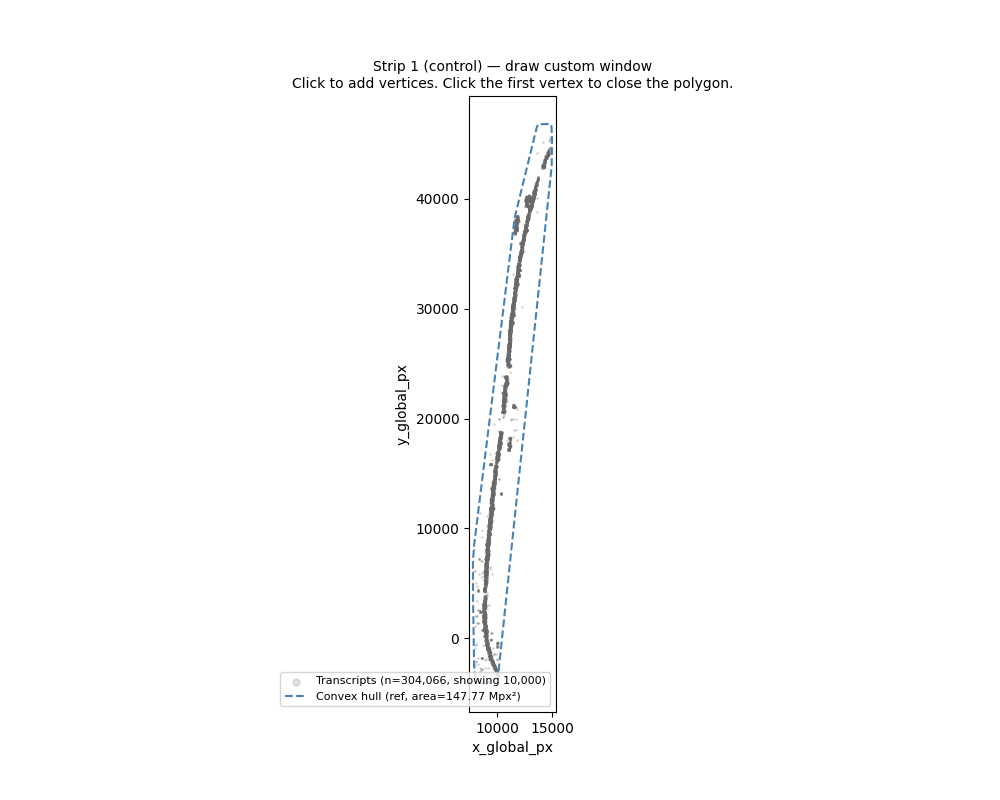

In [4]:
%matplotlib widget
strip_df_1 = all_strips_clean[all_strips_clean['strip'] == 'strip_1']
selector_1 = draw_custom_window(
    strip_df_1,
    save_path='../data/processed/custom_window_strip_1.json',
    strip_name='Strip 1 (control)',
)

In [6]:
# Verification — run after drawing
poly_1 = load_custom_window('../data/processed/custom_window_strip_1.json')
hull_1 = _get_convex_hull_for_strip(strip_df_1)
print(f'Strip 1 custom window:')
print(f'  Vertices:   {len(poly_1.exterior.coords) - 1}')
print(f'  Area:       {poly_1.area/1e6:.3f} Mpx\u00b2')
print(f'  Valid:      {poly_1.is_valid}')
print(f'  Hull area:  {hull_1.area/1e6:.3f} Mpx\u00b2')
print(f'  Custom / hull: {poly_1.area / hull_1.area * 100:.1f}%')

Strip 1 custom window:
  Vertices:   52
  Area:       26.320 Mpx²
  Valid:      True
  Hull area:  147.773 Mpx²
  Custom / hull: 17.8%


## Strip 2 — draw custom window

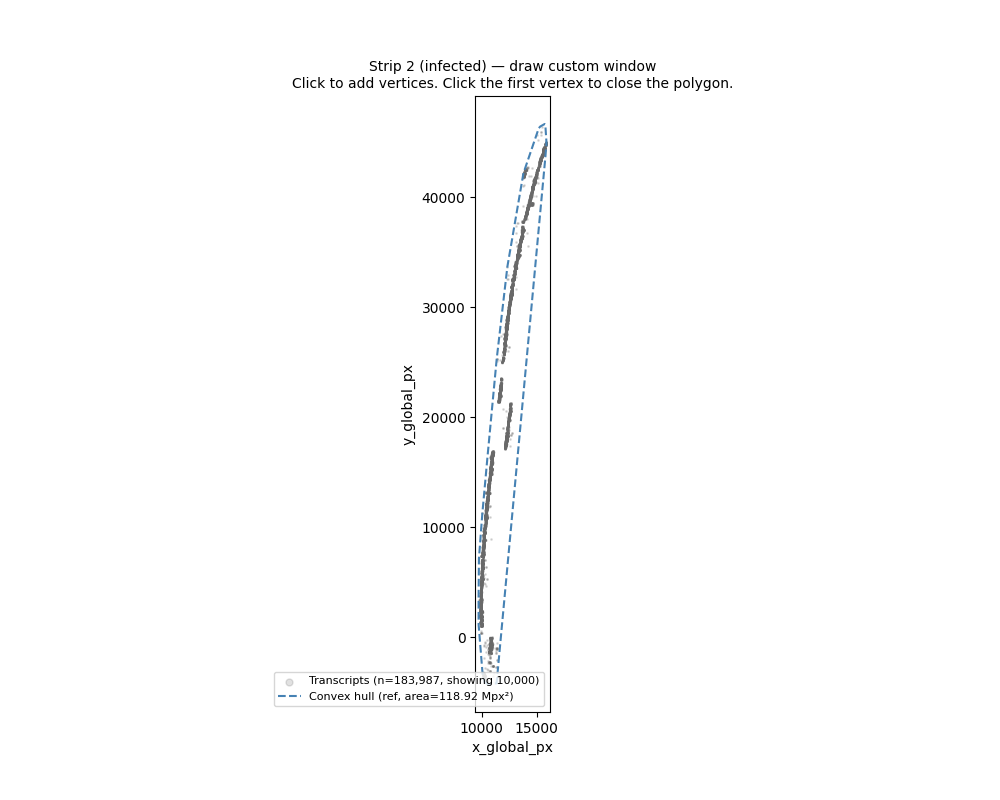

In [7]:
%matplotlib widget
strip_df_2 = all_strips_clean[all_strips_clean['strip'] == 'strip_2']
selector_2 = draw_custom_window(
    strip_df_2,
    save_path='../data/processed/custom_window_strip_2.json',
    strip_name='Strip 2 (infected)',
)

In [8]:
poly_2 = load_custom_window('../data/processed/custom_window_strip_2.json')
hull_2 = _get_convex_hull_for_strip(strip_df_2)
print(f'Strip 2 custom window:')
print(f'  Vertices:   {len(poly_2.exterior.coords) - 1}')
print(f'  Area:       {poly_2.area/1e6:.3f} Mpx\u00b2')
print(f'  Valid:      {poly_2.is_valid}')
print(f'  Hull area:  {hull_2.area/1e6:.3f} Mpx\u00b2')
print(f'  Custom / hull: {poly_2.area / hull_2.area * 100:.1f}%')

Strip 2 custom window:
  Vertices:   45
  Area:       18.098 Mpx²
  Valid:      True
  Hull area:  118.916 Mpx²
  Custom / hull: 15.2%


## Strip 3 — draw custom window

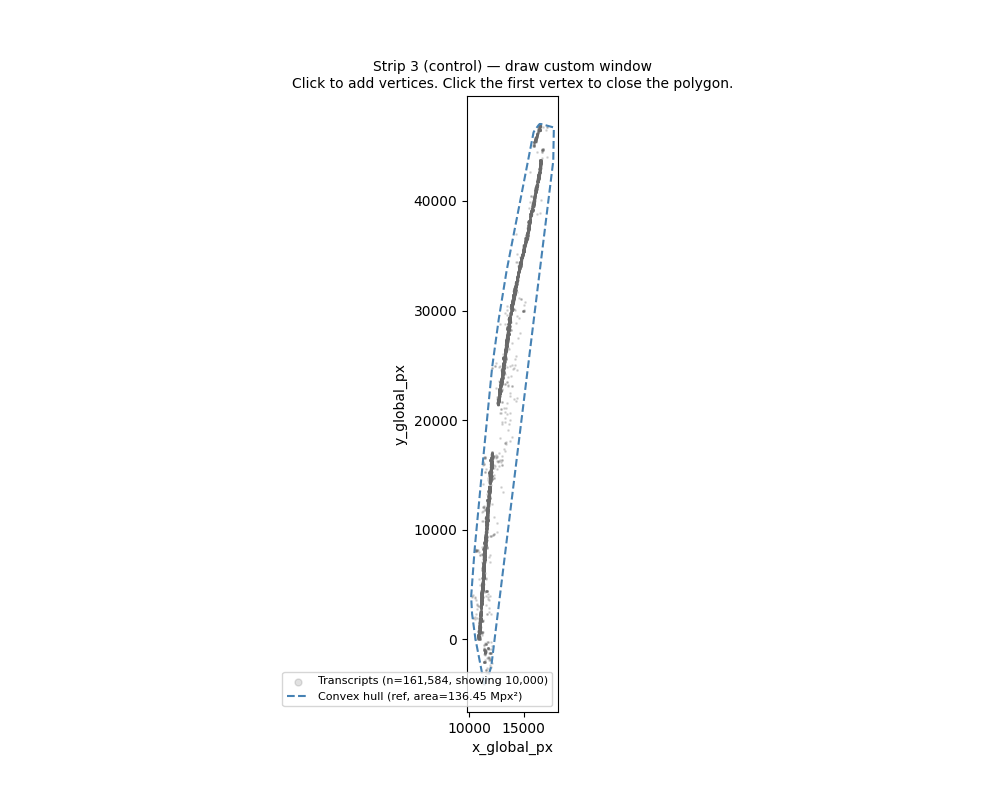

In [10]:
%matplotlib widget
strip_df_3 = all_strips_clean[all_strips_clean['strip'] == 'strip_3']
selector_3 = draw_custom_window(
    strip_df_3,
    save_path='../data/processed/custom_window_strip_3.json',
    strip_name='Strip 3 (control)',
)

In [11]:
poly_3 = load_custom_window('../data/processed/custom_window_strip_3.json')
hull_3 = _get_convex_hull_for_strip(strip_df_3)
print(f'Strip 3 custom window:')
print(f'  Vertices:   {len(poly_3.exterior.coords) - 1}')
print(f'  Area:       {poly_3.area/1e6:.3f} Mpx\u00b2')
print(f'  Valid:      {poly_3.is_valid}')
print(f'  Hull area:  {hull_3.area/1e6:.3f} Mpx\u00b2')
print(f'  Custom / hull: {poly_3.area / hull_3.area * 100:.1f}%')

Strip 3 custom window:
  Vertices:   38
  Area:       20.249 Mpx²
  Valid:      True
  Hull area:  136.452 Mpx²
  Custom / hull: 14.8%


## Summary

Review all three windows together to check they are consistent.

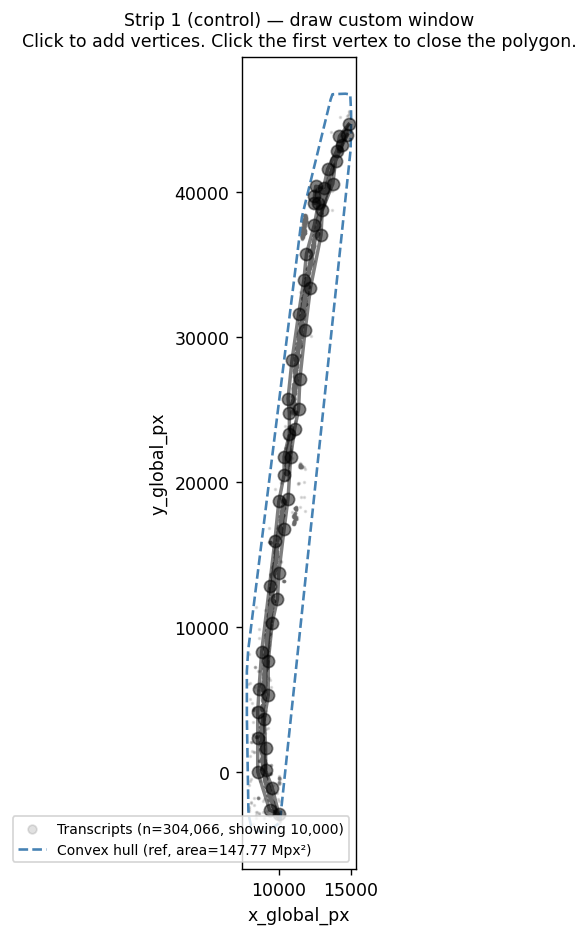

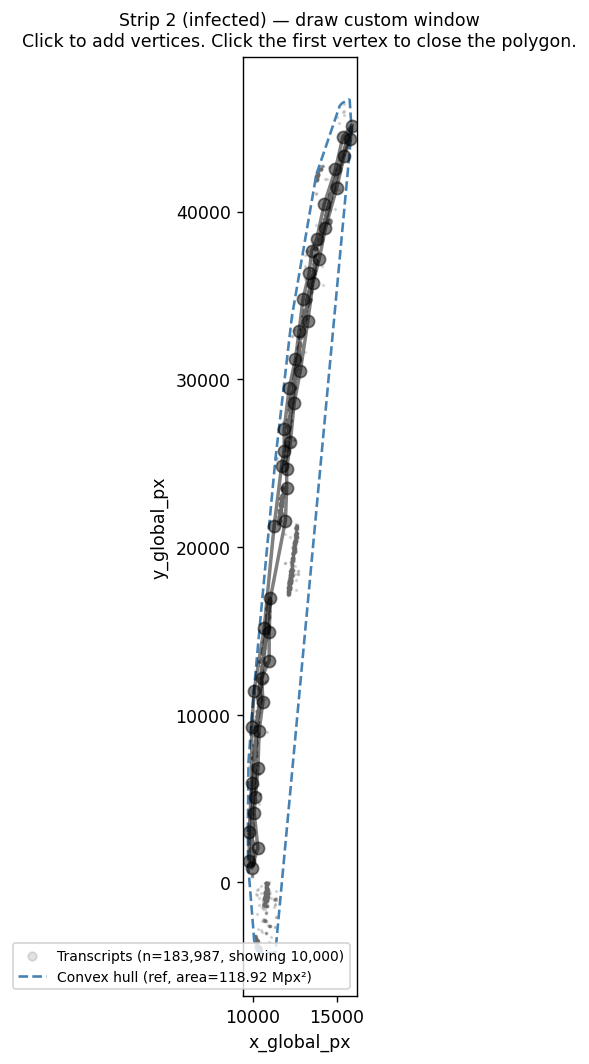

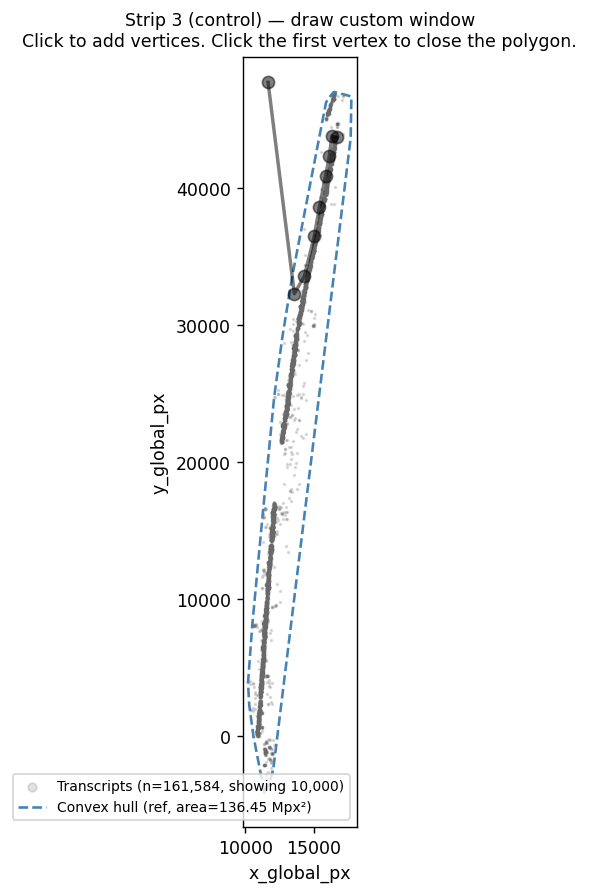

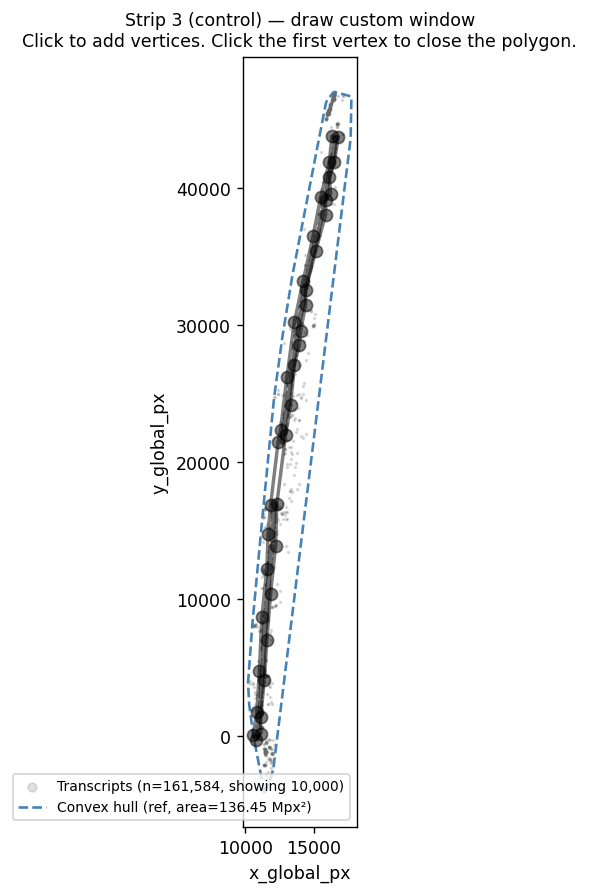

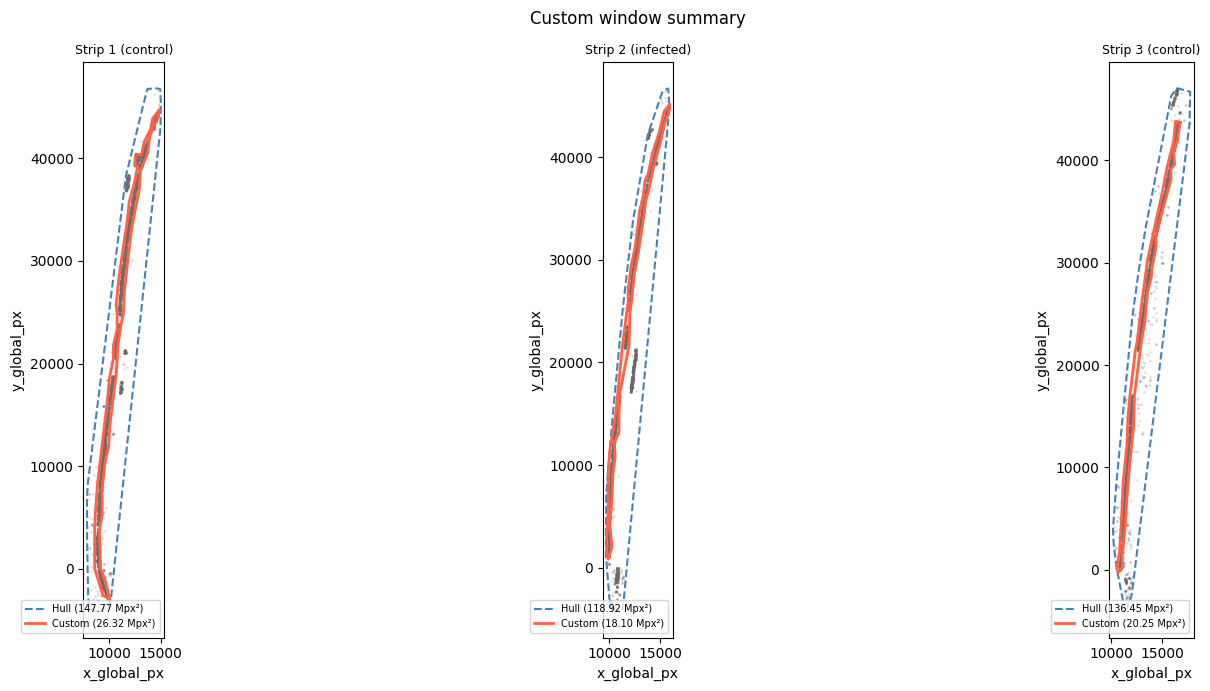

In [12]:
%matplotlib inline
strip_polys = {
    'strip_1': ('Strip 1 (control)',  poly_1, hull_1, strip_df_1),
    'strip_2': ('Strip 2 (infected)', poly_2, hull_2, strip_df_2),
    'strip_3': ('Strip 3 (control)',  poly_3, hull_3, strip_df_3),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
rng_s = np.random.default_rng(0)

for ax, (strip, (label, custom, hull, sdf)) in zip(axes, strip_polys.items()):
    coords = sdf[[X_COL, Y_COL]].values
    n_show = min(len(coords), 8_000)
    idx = rng_s.choice(len(coords), n_show, replace=False)
    ax.scatter(coords[idx, 0], coords[idx, 1],
               s=1, alpha=0.15, c='dimgrey', rasterized=True)

    if hull.geom_type == 'Polygon':
        hx, hy = hull.exterior.xy
        ax.plot(hx, hy, color='steelblue', lw=1.5, linestyle='--',
                label=f'Hull ({hull.area/1e6:.2f} Mpx\u00b2)')

    cx, cy = custom.exterior.xy
    ax.fill(cx, cy, color='tomato', alpha=0.12)
    ax.plot(cx, cy, color='tomato', lw=2,
            label=f'Custom ({custom.area/1e6:.2f} Mpx\u00b2)')

    ax.set_title(label, fontsize=9)
    ax.set_xlabel(X_COL)
    ax.set_ylabel(Y_COL)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Custom window summary', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/09b_custom_window_summary.png', dpi=150, bbox_inches='tight')
plt.show()